In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd

from src.database.queries import get_customer_data
from src.preprocessing.clean_data import clean_data
from src.preprocessing.feature_engineering import feature_engineering

from sklearn.model_selection import train_test_split

In [3]:
df = get_customer_data()

df = clean_data(df)

df = feature_engineering(df)

In [4]:
X = df.drop("exited", axis=1)
y = df["exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [7]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [9]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.808
Precision: 0.5891472868217055
Recall   : 0.18673218673218672
F1 Score : 0.2835820895522388
ROC AUC  : 0.7747778595236223


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



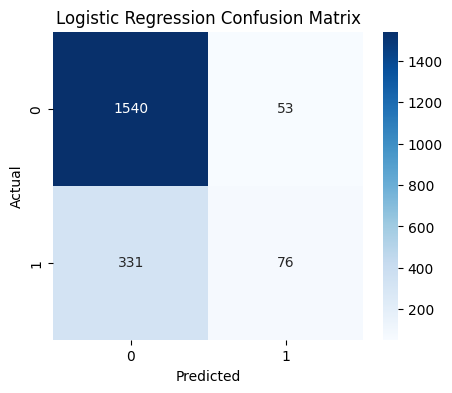

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [12]:
from src.modeling.train import train_logistic_regression
from src.modeling.evaluate import evaluate_model

In [13]:
model, scaler = train_logistic_regression(
    X_train,
    y_train
)

In [23]:
results, y_pred, y_prob = evaluate_model(
    model,
    scaler,
    X_test,
    y_test
)

In [15]:
results

{'Accuracy': 0.808,
 'Precision': 0.5891472868217055,
 'Recall': 0.18673218673218672,
 'F1 Score': 0.2835820895522388,
 'ROC AUC': 0.7747778595236223,
 'Confusion Matrix': array([[1540,   53],
        [ 331,   76]])}

In [19]:
import importlib
import src.modeling.evaluate

importlib.reload(src.modeling.evaluate)

<module 'src.modeling.evaluate' from 'd:\\project\\AI-Banking-Churn-System\\src\\modeling\\evaluate.py'>

In [20]:
from src.modeling.evaluate import evaluate_model

In [21]:
results, y_pred, y_prob = evaluate_model(
    model,
    scaler,
    X_test,
    y_test
)

In [24]:
type(evaluate_model(
    model,
    scaler,
    X_test,
    y_test
))

tuple

In [25]:
results

{'Accuracy': 0.808,
 'Precision': 0.5891472868217055,
 'Recall': 0.18673218673218672,
 'F1 Score': 0.2835820895522388,
 'ROC AUC': 0.7747778595236223,
 'Confusion Matrix': array([[1540,   53],
        [ 331,   76]])}